In [ ]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 7.4 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import re
import string

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

***1. Data Understanding***

In [ ]:
data_t = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/External Resource/tweet.csv')
data_t.sample(10)

,Unnamed: 0,sentimen,tweet
436,436,positif,"mantap, semoga roda ekonomi papua berjalan leb..."
1417,1417,netral,Pernyataan capres @prabowo bhwa kesalahan ekon...
817,817,negatif,"Antek asing, PKI, ekonomi amburadul. harga2 na..."
1527,1527,positif,"MasyaaAllah, baru kali ini seumur2 saya ada ka..."
1165,1165,negatif,Jelas prabowo ga paham konsep ekonomi. https:...
444,444,netral,"Di Korsel banyak yg main game Starcraft, sampe..."
9,9,negatif,Prabowo-Sandi Sepakat Tak Ambil Gaji karena Ne...
595,595,netral,AHY Geram ke Prabowo Gara-gara Ini - Warta Eko...
585,585,netral,"Unk saat ini aku memang makan gaji lae,,tapi t..."
1610,1610,netral,Memimpin itu perlu ke ikhlasan.. Klo nyari gaj...


In [ ]:
data_t.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1815 entries, 0 to 1814
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  1815 non-null   int64 
 1   sentimen    1815 non-null   object
 2   tweet       1815 non-null   object
dtypes: int64(1), object(2)
memory usage: 42.7+ KB


**Cek adakah kosong dan duplikat**

In [ ]:
data_t.duplicated().sum()

np.int64(0)

In [ ]:
data_t.isnull().sum()

,0
Unnamed: 0,0
sentimen,0
tweet,0


**Mengambil kolom tweet dan sentimen dan dijadikan dataset data_olah**




In [ ]:
data_olah = data_t[['tweet','sentimen']]

In [ ]:
data_olah.head()

,tweet,sentimen
0,Kata @prabowo Indonesia tidak dihargai bangsa ...,negatif
1,"Batuan Langka, Tasbih Jokowi Hadiah dari Habib...",netral
2,"Di era Jokowi, ekonomi Indonesia semakin baik....",netral
3,"Bagi Sumatera Selatan, Asian Games berdampak p...",positif
4,Negara kita ngutang buat bngun infrastruktur y...,negatif


***Split Antara Testing dan Training***

In [ ]:
from sklearn.model_selection import train_test_split

x_tweet = data_olah['tweet']
y_tweet = data_olah['sentimen']

x_train, x_test, y_train, y_test = train_test_split(
    x_tweet, y_tweet,
    test_size=0.2,
    random_state=42
)

In [ ]:
x_train.shape

(1452,)

In [ ]:
x_test.shape

(363,)

In [ ]:
data_train = pd.DataFrame({'tweet': x_train, 'sentimen': y_train})
data_train

,tweet,sentimen
609,Komentarnya bagus. Tapi alangkah indshnya jika...,positif
844,Jokowi: Pertumbuhan Ekonomi >5% Harus Disyukur...,netral
300,"Buat yang ciwi-ciwi, mau harga skincare turun?...",netral
1702,"Alhamdulillah,penutup terkeren dr @prabowo Da...",positif
614,"Pun dari hal yang diutarakan Jokowi kemaren, e...",netral
...,...,...
1130,Jelas salah pemerintah yg membuat hukumnya ga ...,negatif
1294,Yg dikatakan Pak @prabowo itu benar. Kita semu...,positif
860,"Namanya juga jaman modern, gaji ya ditransfer ...",netral
1459,"Alhamdulillah,smoga terlaksana cita2 #prabowos...",positif


In [ ]:
data_test = pd.DataFrame({'tweet': x_test, 'sentimen': y_test})
data_test

,tweet,sentimen
567,"Bukan hanya kurang milenial, tapi memang dia s...",negatif
432,artinya presiden yg ke 6 tdk menerima gaji.pra...,positif
1750,Kalau menurut saya bang @sandiuno dan bapak ...,positif
674,Bukan hanya ekonomi aja Pak....namun kehidupan...,negatif
111,"Gak ngaruh, jokowi mau ke kutub utara juga, ra...",negatif
...,...,...
1125,FYI: Digital ekonomi yang di paparkan oleh caw...,positif
1142,"Jelas : "" Prabowo dalam debat kelima menyebut ...",netral
1512,gaji prabowo-sandi bakal buat kaum yatim & dhu...,positif
170,@jokowi @mohmahfudmd @SBYudhoyono @setkabgoid ...,netral


In [ ]:
data_train['sentimen'].value_counts()

,count
sentimen,
netral,489
positif,482
negatif,481


In [ ]:
data_test['sentimen'].value_counts()

,count
sentimen,
positif,130
netral,118
negatif,115


**Visualisasi Distribusi Label**

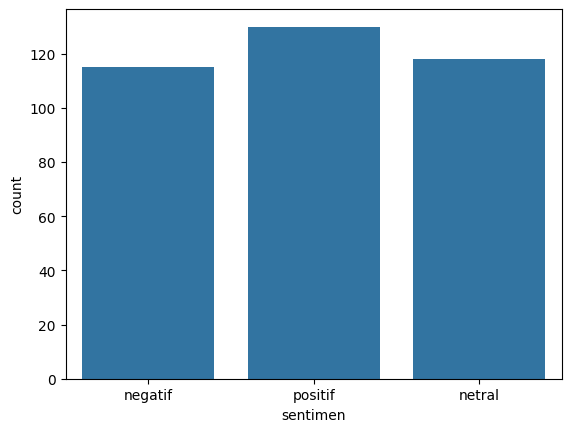

In [ ]:
sns.countplot(x='sentimen', data=data_test)
plt.show()

In [ ]:
data_train

,tweet,sentimen
609,Komentarnya bagus. Tapi alangkah indshnya jika...,positif
844,Jokowi: Pertumbuhan Ekonomi >5% Harus Disyukur...,netral
300,"Buat yang ciwi-ciwi, mau harga skincare turun?...",netral
1702,"Alhamdulillah,penutup terkeren dr @prabowo Da...",positif
614,"Pun dari hal yang diutarakan Jokowi kemaren, e...",netral
...,...,...
1130,Jelas salah pemerintah yg membuat hukumnya ga ...,negatif
1294,Yg dikatakan Pak @prabowo itu benar. Kita semu...,positif
860,"Namanya juga jaman modern, gaji ya ditransfer ...",netral
1459,"Alhamdulillah,smoga terlaksana cita2 #prabowos...",positif


In [ ]:
data_test

,tweet,sentimen
567,"Bukan hanya kurang milenial, tapi memang dia s...",negatif
432,artinya presiden yg ke 6 tdk menerima gaji.pra...,positif
1750,Kalau menurut saya bang @sandiuno dan bapak ...,positif
674,Bukan hanya ekonomi aja Pak....namun kehidupan...,negatif
111,"Gak ngaruh, jokowi mau ke kutub utara juga, ra...",negatif
...,...,...
1125,FYI: Digital ekonomi yang di paparkan oleh caw...,positif
1142,"Jelas : "" Prabowo dalam debat kelima menyebut ...",netral
1512,gaji prabowo-sandi bakal buat kaum yatim & dhu...,positif
170,@jokowi @mohmahfudmd @SBYudhoyono @setkabgoid ...,netral


***2. TEXT PROCESSING***

Rencana yang akan dilakukan adalah

```
1 Lowercase
2 Remove URL
3 Remove Mention
4 Remove Hashtag
5 Remove punctuation
6 Remove number
7 Remove weird character
8 Normalisasi
9 Negasi
10 Remove stopwords
11 Stemming
```



In [ ]:
#Inisialisasi Stemmer dan Stopword

factory = StemmerFactory()
stemmer = factory.create_stemmer()

stop_factory = StopWordRemoverFactory()
stopwords = stop_factory.get_stop_words()

In [ ]:
#function cleaning Text

def clean_text_dummy(text):

    text = text.lower()

    # remove url
    text = re.sub(r'http\S+', '', text)

    # remove mention
    text = re.sub(r'@(\w+)', r'\1', text)

    # remove hashtag
    text = re.sub(r'#(\w+)', r'\1', text)

    # remove number
    text = re.sub(r'\d+', '', text)

    # remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # remove extra whitespace
    text = text.strip()

    return text

In [ ]:
# Proses cleaning
# data_train['clean_tweet'] = data_train['tweet'].apply(clean_text_dummy)

In [ ]:
normalisasi = { "yg": "yang", "dgn": "dengan", "dg": "dengan", "tdk": "tidak", "gk": "tidak"
, "ga": "tidak", "nggak": "tidak", "tak": "tidak", "bkn": "bukan", "krn": "karena"
, "dr": "dari", "dlm": "dalam", "pd": "pada", "utk": "untuk", "jd": "jadi", "jg": "juga"
, "sm": "sama", "sama2": "sama sama", "sy": "saya", "sya": "saya", "gw": "saya", "gue": "saya"
, "aku": "saya", "km": "kamu", "kmu": "kamu", "loe": "kamu", "lu": "kamu", "org": "orang"
, "byk": "banyak", "bnyk": "banyak", "sdh": "sudah", "udh": "sudah", "blm": "belum"
, "hrs": "harus", "hrus": "harus", "bs": "bisa", "bsa": "bisa", "aja": "saja", "doang": "saja"
, "tok": "saja", "nih": "ini", "ni": "ini", "ituu": "itu", "bgt": "banget", "bgtt": "banget"
, "amat": "sangat", "sangattt": "sangat", "tp": "tapi", "tpi": "tapi", "knp": "kenapa", "kpn": "kapan"
, "gmn": "bagaimana", "gmna": "bagaimana", "mn": "mana", "drmn": "darimana", "dimn": "dimana", "kmn": "kemana"
, "pgn": "ingin", "pngen": "ingin", "mau": "ingin", "trs": "terus", "trus": "terus", "udh": "sudah", "lg": "lagi"
, "lgi": "lagi", "skrg": "sekarang", "skrng": "sekarang", "dpt": "dapat", "dapet": "dapat", "ngasih": "memberi"
, "ngasi": "memberi", "ngambil": "mengambil", "ngaku": "mengaku", "ngomong": "berbicara", "ngeliat": "melihat"
, "ngerti": "mengerti", "pke": "pakai", "pkai": "pakai", "pakaii": "pakai", "krja": "kerja", "kerja2": "kerja kerja"
, "rkyat": "rakyat", "indo": "indonesia", "ind": "indonesia", "negri": "negeri"
, "pemrintah": "pemerintah", "presidenya": "presidennya", "pemimpin2": "pemimpin pemimpin"
}

In [ ]:
# Function Normalisasi
def normalize_text(text):

    words = text.split()

    normalized = [normalisasi[word] if word in normalisasi else word for word in words]

    return " ".join(normalized)

In [ ]:
# Menjalankan normalisasi
# data_train['clean_tweet'] = data_train['clean_tweet'].apply(normalize_text)

In [ ]:
# Function Menghilangkan Stopword
# =============================
# 1. Daftar kata negasi
# =============================

negasi = [
    "tidak","bukan","tak","kurang","tdk",
    "gak","ga","gk","nggak","ngga","enggak",
    "belum","jangan"
]


# =============================
# 2. Ambil stopword dari Sastrawi
# =============================

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

factory = StopWordRemoverFactory()
stopwords = factory.get_stop_words()


# =============================
# 3. Pastikan negasi tidak ada di stopword
# =============================

stopwords = set(stopwords) - set(negasi)


# =============================
# 4. Function Menghilangkan Stopword
# =============================

def remove_stopwords(text):

    # menghindari error jika text kosong
    if not isinstance(text, str):
        return ""

    words = text.split()

    filtered = [word for word in words if word not in stopwords]

    return " ".join(filtered)

In [ ]:
# menjalankan menghilangkan stopword
# data_train['clean_tweet'] = data_train['clean_tweet'].apply(remove_stopwords)

In [ ]:
# Function Stemming
def stemming(text):

    return stemmer.stem(text)

In [ ]:
#menjalankan Stemmming
# data_train['clean_tweet'] = data_train['clean_tweet'].apply(stemming)

In [ ]:
#function Negasi Handling

def handle_negation(text):
    negasi = ["tidak","bukan","gak","ga","nggak","tak","kurang","tdk","enggak","gk","ngga","nda","ndak","jangan","belum"]

    words = text.split()
    result = []
    skip = False

    for i in range(len(words)):
        if skip:
            skip = False
            continue

        if words[i] in negasi and i+1 < len(words):
            result.append(words[i] + "_" + words[i+1])
            skip = True
        else:
            result.append(words[i])

    return " ".join(result)

In [ ]:
# menjalankan menghilangkan Negasi
# data_train['clean_tweet'] = data_train['clean_tweet'].apply(handle_negation)

In [ ]:
# Proses cleaning
data_train['clean_tweet'] = data_train['tweet'].apply(clean_text_dummy)

# Menjalankan normalisasi
data_train['clean_tweet'] = data_train['clean_tweet'].apply(normalize_text)

# menjalankan menghilangkan stopword
data_train['clean_tweet'] = data_train['clean_tweet'].apply(remove_stopwords)

#menjalankan Stemmming
data_train['clean_tweet'] = data_train['clean_tweet'].apply(stemming)

# menjalankan menghilangkan Negasi
data_train['clean_tweet'] = data_train['clean_tweet'].apply(handle_negation)


In [ ]:
data_train

,tweet,sentimen,clean_tweet
609,Komentarnya bagus. Tapi alangkah indshnya jika...,positif,komentar bagus alangkah indshnya ibu bilang jo...
844,Jokowi: Pertumbuhan Ekonomi >5% Harus Disyukur...,netral,jokowi tumbuh ekonomi syukur jangan_kufur nikm...
300,"Buat yang ciwi-ciwi, mau harga skincare turun?...",netral,buat ciwiciwi harga skincare turun tusuk prabo...
1702,"Alhamdulillah,penutup terkeren dr @prabowo Da...",positif,alhamdulillahpenutup keren prabowo sandiuno ti...
614,"Pun dari hal yang diutarakan Jokowi kemaren, e...",netral,utara jokowi kemaren esports sendiri memang be...
...,...,...,...
1130,Jelas salah pemerintah yg membuat hukumnya ga ...,negatif,jelas salah perintah buat hukum tidak_ketat co...
1294,Yg dikatakan Pak @prabowo itu benar. Kita semu...,positif,kata pak prabowo benar semua tanggung jawab ul...
860,"Namanya juga jaman modern, gaji ya ditransfer ...",netral,nama jaman modern gaji transfer bukan_ambil pi...
1459,"Alhamdulillah,smoga terlaksana cita2 #prabowos...",positif,alhamdulillahsmoga laksana cita prabowosandiaa...


***Preprocessing data Testing***

In [ ]:
# Proses cleaning
data_test['clean_tweet'] = data_test['tweet'].apply(clean_text_dummy)

# Menjalankan normalisasi
data_test['clean_tweet'] = data_test['clean_tweet'].apply(normalize_text)

# menjalankan menghilangkan stopword
data_test['clean_tweet'] = data_test['clean_tweet'].apply(remove_stopwords)

#menjalankan Stemmming
data_test['clean_tweet'] = data_test['clean_tweet'].apply(stemming)

# menjalankan menghilangkan Negasi
data_test['clean_tweet'] = data_test['clean_tweet'].apply(handle_negation)

In [ ]:
data_test

,tweet,sentimen,clean_tweet
567,"Bukan hanya kurang milenial, tapi memang dia s...",negatif,bukan_kurang milenial memang sama sekali tidak...
432,artinya presiden yg ke 6 tdk menerima gaji.pra...,positif,arti presiden tidak_terima gajiprabowo sandi l...
1750,Kalau menurut saya bang @sandiuno dan bapak ...,positif,kalau bang sandiuno bapak prabowo mampu tempat...
674,Bukan hanya ekonomi aja Pak....namun kehidupan...,negatif,bukan_ekonomi paknamun hidup buruh korbanphkil...
111,"Gak ngaruh, jokowi mau ke kutub utara juga, ra...",negatif,gak_ngaruh jokowi kutub utara rakyat tau baran...
...,...,...,...
1125,FYI: Digital ekonomi yang di paparkan oleh caw...,positif,fyi digital ekonomi papar cawapres laku era pe...
1142,"Jelas : "" Prabowo dalam debat kelima menyebut ...",netral,jelas prabowo debat lima sebut soal ekonomi de...
1512,gaji prabowo-sandi bakal buat kaum yatim & dhu...,positif,gaji prabowosandi bakal buat kaum yatim dhuafa...
170,@jokowi @mohmahfudmd @SBYudhoyono @setkabgoid ...,netral,jokowi mohmahfudmd sbyudhoyono setkabgoid sala...


***3. Vectorization***

**Random Forest**

***Melakukan encoding untuk data sentimen***

```
negatif = 0
netral = 1
positif = 2
```


In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
encoder = LabelEncoder()

y_train = data_train['sentimen']
y_train_encode = encoder.fit_transform(y_train)

y_test = data_test['sentimen']
y_test_encode = encoder.transform(y_test)

In [ ]:
y_test_encode

array([0, 2, 2, 0, 0, 1, 1, 1, 1, 0, 2, 2, 0, 1, 0, 2, 0, 0, 1, 2, 0, 0,
       0, 1, 1, 2, 1, 1, 0, 0, 0, 2, 0, 0, 1, 0, 0, 2, 2, 1, 0, 2, 1, 1,
       2, 0, 2, 2, 2, 1, 2, 2, 1, 2, 0, 0, 1, 2, 0, 2, 2, 0, 0, 2, 2, 2,
       2, 0, 0, 1, 0, 0, 2, 2, 1, 2, 0, 2, 0, 1, 2, 1, 2, 2, 0, 2, 1, 2,
       2, 1, 0, 0, 1, 1, 1, 0, 0, 0, 2, 0, 1, 0, 2, 1, 2, 2, 2, 2, 1, 0,
       1, 2, 2, 1, 0, 0, 2, 1, 0, 0, 2, 0, 2, 1, 0, 1, 1, 2, 2, 2, 0, 2,
       2, 0, 2, 2, 1, 0, 1, 1, 2, 2, 1, 2, 1, 1, 1, 2, 1, 2, 0, 1, 2, 0,
       1, 1, 2, 2, 0, 1, 1, 2, 0, 0, 1, 0, 1, 1, 2, 1, 0, 1, 2, 1, 2, 2,
       0, 2, 2, 2, 2, 1, 2, 0, 1, 1, 2, 1, 1, 0, 1, 0, 1, 1, 1, 2, 2, 0,
       1, 0, 1, 2, 1, 0, 2, 0, 2, 1, 0, 1, 0, 1, 0, 1, 2, 1, 0, 2, 2, 1,
       2, 2, 0, 2, 2, 0, 1, 2, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 2, 2, 2, 2, 2, 1, 2, 2, 2, 1, 1, 2, 0, 0, 0, 0, 2, 2, 1, 2,
       2, 1, 2, 0, 2, 0, 2, 2, 1, 1, 0, 0, 2, 1, 1, 2, 1, 0, 0, 0, 1, 2,
       1, 2, 0, 0, 1, 0, 0, 2, 2, 1, 1, 0, 1, 0, 2,

***Melakukan TF-IDF***

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
tfidf = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1,2),
    min_df=3,
    max_df=0.9,
    sublinear_tf=True)

Fit pada training data (Fit hanya untuk Training Data)

In [ ]:
x_train_tfidf = tfidf.fit_transform(x_train)

Transform pada Testing data (Test Tidak boleh di fit)

In [ ]:
x_test_tfidf = tfidf.transform(x_test)

In [ ]:
print(x_train_tfidf.shape)
print(x_test_tfidf.shape)

(1452, 3000)
(363, 3000)


***Training Random Forest***

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_train = RandomForestClassifier(
    n_estimators=300,
    random_state=42
    ,class_weight='balanced'
)

***Buat Model***

In [ ]:
rf_train.fit(x_train_tfidf, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

*Prediksi*

In [ ]:
y_pred = rf_train.predict(x_test_tfidf)

***Evaluasi***

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.559228650137741
              precision    recall  f1-score   support

     negatif       0.55      0.67      0.60       115
      netral       0.61      0.55      0.58       118
     positif       0.52      0.47      0.49       130

    accuracy                           0.56       363
   macro avg       0.56      0.56      0.56       363
weighted avg       0.56      0.56      0.56       363

[[77 15 23]
 [20 65 33]
 [43 26 61]]


***Training random Forest + GridSearch***

**Menjalankan Grid Search**

In [ ]:
from sklearn.model_selection import GridSearchCV


param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

grid_rf_accuracy = GridSearchCV(
    estimator=rf_train,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_rf_recall = GridSearchCV(
    estimator=rf_train,
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

grid_rf_precision = GridSearchCV(
    estimator=rf_train,
    param_grid=param_grid,
    cv=5,
    scoring='precision',
    n_jobs=-1,
    verbose=1
)


grid_rf_precision_weighted = GridSearchCV(
    estimator=rf_train,
    param_grid=param_grid,
    cv=5,
    scoring='precision_weighted',
    n_jobs=-1,
    verbose=1
)

grid_rf_recall_weighted = GridSearchCV(
    estimator=rf_train,
    param_grid=param_grid,
    cv=5,
    scoring='recall_weighted',
    n_jobs=-1,
    verbose=1
)

***Training GridSearch***

In [ ]:
grid_rf_accuracy.fit(x_train_tfidf, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              n_estimators=300,
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy', verbose=1)

In [ ]:
grid_rf_recall.fit(x_train_tfidf, y_train)


Fitting 5 folds for each of 72 candidates, totalling 360 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              n_estimators=300,
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200, 300]},
             scoring='recall', verbose=1)

In [ ]:
grid_rf_precision.fit(x_train_tfidf, y_train)


Fitting 5 folds for each of 72 candidates, totalling 360 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              n_estimators=300,
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200, 300]},
             scoring='precision', verbose=1)

In [ ]:
grid_rf_precision_weighted.fit(x_train_tfidf, y_train)


Fitting 5 folds for each of 72 candidates, totalling 360 fits


GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              n_estimators=300,
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200, 300]},
             scoring='precision_weighted', verbose=1)

In [ ]:
grid_rf_recall_weighted.fit(x_train_tfidf, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              n_estimators=300,
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200, 300]},
             scoring='recall_weighted', verbose=1)

***Cek Parameter Terbaik***

In [ ]:
print("Best Parameters accuracy:", grid_rf_accuracy.best_params_)
print("Best CV Score accuracy:", grid_rf_accuracy.best_score_)

print("Best Parameters recall:", grid_rf_recall.best_params_)
print("Best CV Score recall:", grid_rf_recall.best_score_)

print("Best Parameters precision:", grid_rf_precision.best_params_)
print("Best CV Score precision:", grid_rf_precision.best_score_)

print("Best Parameters precision_weighted:", grid_rf_precision_weighted.best_params_)
print("Best CV Score precision_weighted:", grid_rf_precision_weighted.best_score_)

print("Best Parameters recall_weighted:", grid_rf_recall_weighted.best_params_)
print("Best CV Score recall_weighted:", grid_rf_recall_weighted.best_score_)

Best Parameters accuracy: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV Score accuracy: 0.6253631946913141
Best Parameters recall: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Score recall: nan
Best Parameters precision: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Score precision: nan
Best Parameters precision_weighted: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV Score precision_weighted: 0.6337646048124067
Best Parameters recall_weighted: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV Score recall_weighted: 0.6253631946913141


***Menentukan Model terbaik nya***

In [ ]:
best_rf_accuracy = grid_rf_accuracy.best_estimator_
best_rf_recall = grid_rf_recall.best_estimator_
best_rf_precision = grid_rf_precision.best_estimator_
best_rf_precision_weighted = grid_rf_precision_weighted.best_estimator_
best_rf_recall_weighted = grid_rf_recall_weighted.best_estimator_

***Prediksi Random Forest***

In [ ]:
y_gridsearch_pred_accuracy = grid_rf_accuracy.predict(x_test_tfidf)
y_gridsearch_pred_recall = grid_rf_recall.predict(x_test_tfidf)
y_gridsearch_pred_precision = grid_rf_precision.predict(x_test_tfidf)
y_gridsearch_pred_precision_weight = grid_rf_precision_weighted.predict(x_test_tfidf)
y_gridsearch_pred_recall_weighted = grid_rf_recall_weighted.predict(x_test_tfidf)

***Evaluasi Model Random Forest***

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy y_gridsearch_pred_accuracy:", accuracy_score(y_test, y_gridsearch_pred_accuracy))
print(classification_report(y_test, y_gridsearch_pred_accuracy))
print(confusion_matrix(y_test, y_gridsearch_pred_accuracy))
print("---------")
print("Accuracy y_gridsearch_pred_recall:", accuracy_score(y_test, y_gridsearch_pred_recall))
print(classification_report(y_test, y_gridsearch_pred_recall))
print(confusion_matrix(y_test, y_gridsearch_pred_recall))
print("---------")
print("Accuracy y_gridsearch_pred_precision:", accuracy_score(y_test, y_gridsearch_pred_precision))
print(classification_report(y_test, y_gridsearch_pred_precision))
print(confusion_matrix(y_test, y_gridsearch_pred_precision))
print("---------")
print("Accuracy y_gridsearch_pred_precision_weight:", accuracy_score(y_test, y_gridsearch_pred_precision_weight))
print(classification_report(y_test, y_gridsearch_pred_precision_weight))
print(confusion_matrix(y_test, y_gridsearch_pred_precision_weight))
print("---------")
print("Accuracy y_gridsearch_pred_recall_weighted:", accuracy_score(y_test, y_gridsearch_pred_recall_weighted))
print(classification_report(y_test, y_gridsearch_pred_recall_weighted))
print(confusion_matrix(y_test, y_gridsearch_pred_recall_weighted))
print("---------")

Accuracy y_gridsearch_pred_accuracy: 0.5730027548209367
              precision    recall  f1-score   support

     negatif       0.55      0.71      0.62       115
      netral       0.64      0.58      0.61       118
     positif       0.54      0.45      0.49       130

    accuracy                           0.57       363
   macro avg       0.58      0.58      0.57       363
weighted avg       0.58      0.57      0.57       363

[[82 15 18]
 [19 68 31]
 [49 23 58]]
---------
Accuracy y_gridsearch_pred_recall: 0.5482093663911846
              precision    recall  f1-score   support

     negatif       0.50      0.70      0.58       115
      netral       0.61      0.50      0.55       118
     positif       0.56      0.46      0.51       130

    accuracy                           0.55       363
   macro avg       0.56      0.55      0.55       363
weighted avg       0.56      0.55      0.54       363

[[80 16 19]
 [31 59 28]
 [49 21 60]]
---------
Accuracy y_gridsearch_pred_precisi



```
Berdasarkan Evaluasi nilai accurasi nya masih sekitar 0.57
```

